# Scottish Premiership Manager Survival Analysis
## A Cox Proportional Hazards Model of Managerial Tenure

**Author:** Jake Oliver

**Date:** May 2026

**Data Source:** Transfermarkt.co.uk

## Introduction
This project applies survival analysis to model managerial tenure in the Scottish Premiership. The central question is: **what factors influence how long a manager surivives in their role at a Scottish Premiership club?**

Survival analysis is a branch of statistics concerned with modelling the time until an event of interest occurs - in this case, a manager leaving their post. A key feature of survival analysis is its abaility to handle **censored observations** - managers who are still in charge at the time of the analysis have now yet experienced the event, but their partial survival tine is still informative and is retained in the model.

We apply two core methods from survival anaoysis:

-**Kaplan-Meier Estimation** - a non-parametric method for estimating and visualising survival curves, used here to compare survival across different groupssuch as reason for departure or club.

-**Cox Proportional Hazards Model** - a semi-parametric regression model that estimates the effect of covariates such as PPG and matches in charge on the hazard of departure.

This project was built on a manually complied dataset of all permanent managerial appointments at Scottish Premiership clubs from the year 2000 onwards, sourced from Transfermarkt.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Libraries

-**pandas** - data loading and manipulation

-**numpy** - numerical operations

-**matplotlib** - visualisation

-**statsmodels** - Cox Proportional Hazards regression

## Data

The dataset was manually compiled from Transfermarkt.co.uk and covers all permanent managerial appointments at Scottish Premiership clubs from the year 2000 onwards. Each row represents a single managerial spell and includes the managers name, club, start and end dates, reason for departure, matches in charge, and points per game.

A key feature of survival datasets is the handling of **censored observations** - managers still in charge at the time of analysis have not yet experienced the departure event. These are recorded wirh 'Left = 0' and their tenure is calculated up to todays date retaining their partial information in the model rather than discarding it.

In [6]:
df = pd.read_csv('SPFL Manager Data.csv')
print(df.shape)
df.head()

(174, 8)


,Manager,Club,Start_Date,End_Date,Left,Reason,PPG,Matches
0,Wilfired Nancy,Celtic,04/12/2025,05/01/2026,1,Sacked,0.75,8
1,Brendan Rodgers,Celtic,01/07/2023,27/10/2025,1,Resigned,2.19,123
2,Ange Postecoglu,Celtic,01/06/2021,30/06/2023,1,Resigned,2.31,113
3,Neil Lennon,Celtic,26/02/2019,24/02/2021,1,Resigned,2.30,108
4,Brendan Rodgers,Celtic,20/05/2016,26/02/2019,1,Resigned,2.24,169


## Data Preparation

We parse dates, calculate each manager's tenure in days, and handle censored 
observations by using today's date as the end date for managers still in charge. 
We also create a numerical encoding of the departure reason for use in the model.

In [8]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], dayfirst=True)
df['End_Date'] = pd.to_datetime(df['End_Date'].str.strip(), dayfirst=True, errors='coerce')

# Fill missing end dates with today for censored observations
today = pd.Timestamp.today()
df['End_Date'] = df['End_Date'].fillna(today)

# Calculate tenure in days
df['Tenure_Days'] = (df['End_Date'] - df['Start_Date']).dt.days

# Drop any empty rows
df = df.dropna(subset=['Manager', 'Club'])
df = df.reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())
df.head()

(174, 9)
Manager        0
Club           0
Start_Date     0
End_Date       0
Left           0
Reason         0
PPG            0
Matches        0
Tenure_Days    0
dtype: int64


,Manager,Club,Start_Date,End_Date,Left,Reason,PPG,Matches,Tenure_Days
0,Wilfired Nancy,Celtic,2025-12-04,2026-01-05,1,Sacked,0.75,8,32
1,Brendan Rodgers,Celtic,2023-07-01,2025-10-27,1,Resigned,2.19,123,849
2,Ange Postecoglu,Celtic,2021-06-01,2023-06-30,1,Resigned,2.31,113,759
3,Neil Lennon,Celtic,2019-02-26,2021-02-24,1,Resigned,2.30,108,729
4,Brendan Rodgers,Celtic,2016-05-20,2019-02-26,1,Resigned,2.24,169,1012


In [9]:
print(f"Total spells: {len(df)}")
print(f"Still in charge (censored): {(df['Left'] == 0).sum()}")
print(f"Left (events): {(df['Left'] == 1).sum()}")
print(f"\nAverage tenure (days): {df['Tenure_Days'].mean():.0f}")
print(f"Shortest tenure (days): {df['Tenure_Days'].min()}")
print(f"Longest tenure (days): {df['Tenure_Days'].max()}")
print(f"\nReasons for departure:")
print(df['Reason'].value_counts())

Total spells: 174
Still in charge (censored): 8
Left (events): 166

Average tenure (days): 624
Shortest tenure (days): 32
Longest tenure (days): 2891

Reasons for departure:
Reason
Sacked             73
Resigned           62
Mutual Consent     28
Still In Charge     8
Retired             2
Redundancy          1
Name: count, dtype: int64


### Data Summary

The dataset contains 174 permanent managerial spells across current Scottish Premiership clubs from the year 2000 onwards, of which 166 have ended and 8 are ongoing (censored). The average tenure is 624 days - just under two years - with spells ranging from 32 days to 2,891 days.

Sacking is the most common reason for departure (73 cases), followed by resignation (62 cases) and mutual consent (28 cases). The small number of retirements and redundancies will be grouped with related categories for the analysis.

### Data Dictionary

Each row represents a single managerial spell. The columns are defined as follows:

- **Manager** — full name of the manager
- **Club** — Scottish Premiership club
- **Start_Date** — date the manager took charge
- **End_Date** — date the spell ended, or today's date if still in charge
- **Left** — 1 if the spell has ended, 0 if the manager is still in charge (censored)
- **Reason** — reason for departure, categorised as follows:
    - *Sacked* — contract terminated by the club, including non-renewals
    - *Resigned* — manager chose to leave, including moves to other clubs, 
      rejection of contract extensions, and activation of relegation clauses
    - *Mutual Consent* — departure agreed between both parties
    - *Retired* — manager stepped down permanently from management
    - *Redundancy* — spell ended due to the club entering administration
    - *Still In Charge* — manager is currently in post (censored observation)
- **PPG** — points per game during the spell
- **Matches** — total matches in charge
- **Tenure_Days** — duration of the spell in days, calculated from Start and End dates

## Exploratory Data Analysis (EDA)

Before building the survival model we explore the dataset to understand the distribution of managerial tenures, the breakdown of departure reasons, and any visible patterns across clubs or time periods.

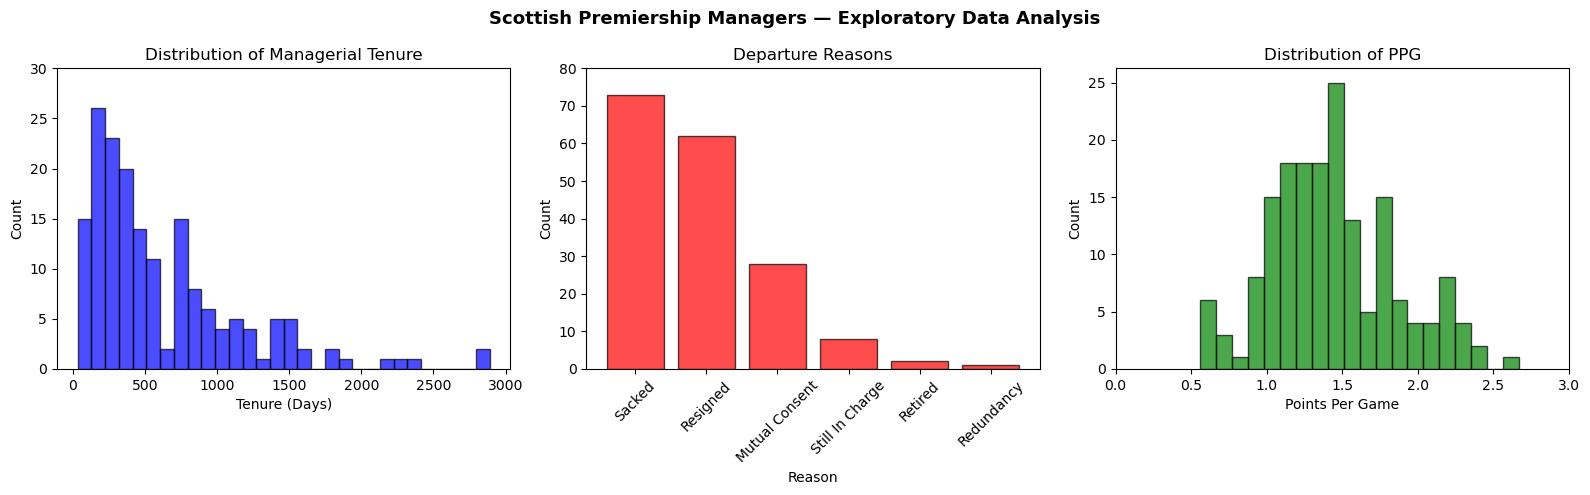

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tenure distribution
axes[0].hist(df['Tenure_Days'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Managerial Tenure')
axes[0].set_xlabel('Tenure (Days)')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 30)

# Departure reasons
reason_counts = df['Reason'].value_counts()
axes[1].bar(reason_counts.index, reason_counts.values, color='red', edgecolor='black', alpha=0.7)
axes[1].set_title('Departure Reasons')
axes[1].set_xlabel('Reason')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 80)
axes[1].tick_params(axis='x', rotation=45)

# PPG distribution
axes[2].hist(df['PPG'].dropna(), bins=20, color='green', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of PPG')
axes[2].set_xlabel('Points Per Game')
axes[2].set_ylabel('Count')
axes[2].set_xlim(0, 3)

plt.suptitle('Scottish Premiership Managers — Exploratory Data Analysis', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Observations

The tenure distribution is strongly right skewed — the majority of managerial spells 
last under 500 days, with a long tail of longer tenures. This is typical of survival 
data where most subjects experience the event early but a small number survive for 
considerably longer.

Sacking and resignation are by far the most common departure reasons, together accounting 
for over 80% of all spell endings. Mutual consent is the next most frequent, with 
retirement and redundancy representing rare edge cases.

The PPG distribution is roughly bell shaped and centred around 1.4-1.5 points per game. 
A PPG of 1.5 in a 3-points-for-a-win system represents winning exactly half of all 
matches, suggesting the dataset is reasonably balanced across clubs of different strengths.

## Kaplan-Meier Survival Analysis

The Kaplan-Meier estimator is a non-parametric method for estimating the survival 
function from observed data. It calculates the probability of a manager surviving 
in their role beyond a given number of days, accounting for censored observations.

We first plot the overall survival curve for all managers, then compare survival 
curves across different departure reason groups to identify whether certain types 
of manager last longer than others.

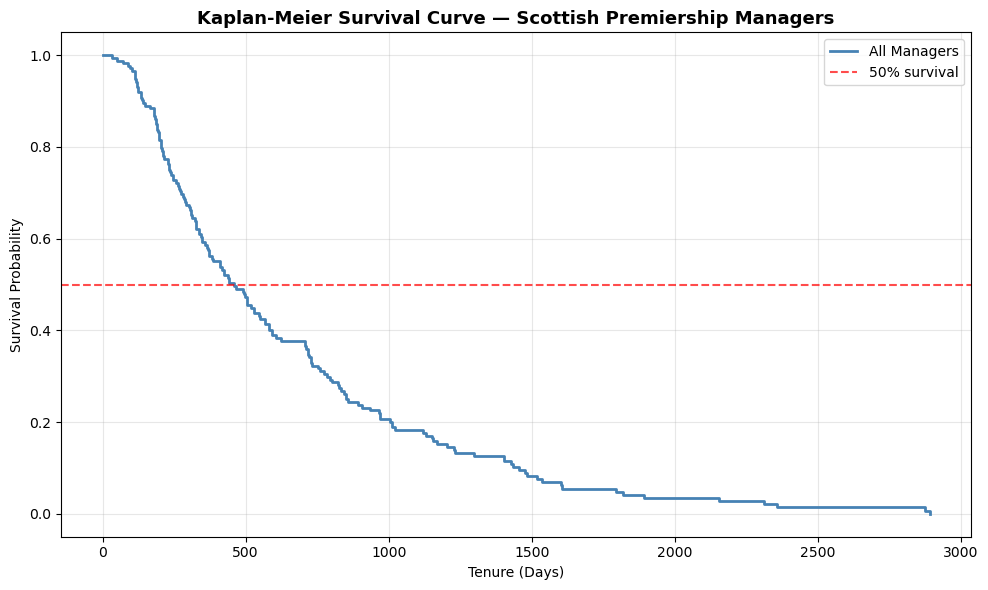

Median survival time: 460 days


In [16]:
def kaplan_meier(durations, events):
    """
    Calculate Kaplan-Meier survival estimate.
    durations: array of tenure lengths in days
    events: array of 1 (left) or 0 (censored)
    Returns: (times, survival probabilities)
    """
    df_km = pd.DataFrame({'duration': durations, 'event': events})
    df_km = df_km.sort_values('duration').reset_index(drop=True)
    
    times = [0]
    survival = [1.0]
    s = 1.0
    
    unique_times = df_km[df_km['event'] == 1]['duration'].unique()
    
    for t in sorted(unique_times):
        n = (df_km['duration'] >= t).sum()  # at risk
        d = ((df_km['duration'] == t) & (df_km['event'] == 1)).sum()  # events
        s *= (1 - d/n)
        times.append(t)
        survival.append(s)
    
    return np.array(times), np.array(survival)

# Overall survival curve
times, survival = kaplan_meier(df['Tenure_Days'], df['Left'])

plt.figure(figsize=(10, 6))
plt.step(times, survival, where='post', color='steelblue', linewidth=2, label='All Managers')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% survival')
plt.title('Kaplan-Meier Survival Curve — Scottish Premiership Managers', 
          fontsize=13, fontweight='bold')
plt.xlabel('Tenure (Days)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find median survival time
median_idx = np.where(survival <= 0.5)[0]
if len(median_idx) > 0:
    print(f"Median survival time: {times[median_idx[0]]} days")

### Overall Survival Curve Interpretation

The Kaplan-Meier curve reveals that managerial tenure in the Scottish Premiership follows a pattern of rapid early decline. The survival probability drops steeply in the first 500 days, reflecting the high turnover of managers who fail to establish themselves quickly.

The median survival time is **460 days** — just over 15 months — meaning half of all permanent managers in the dataset left their post within this period. Beyond 1,500 days the curve flattens considerably, representing a small group of long serving managers who survived significantly longer than average.

This right skewed pattern is characteristic of survival data in high pressure employment contexts where early performance is heavily scrutinised.

### Survival Curves by Departure Reason

We compare curves across the three main departure reason groups - sacked, resigned, and mutual consent. We would expect managers who were sacked to have shorter tenures on average, while those who resigned may have survived longer before choosing to leave on their own terms.

Median survival (Sacked): 368 days
Median survival (Resigned): 707 days
Median survival (Mutual Consent): 372 days


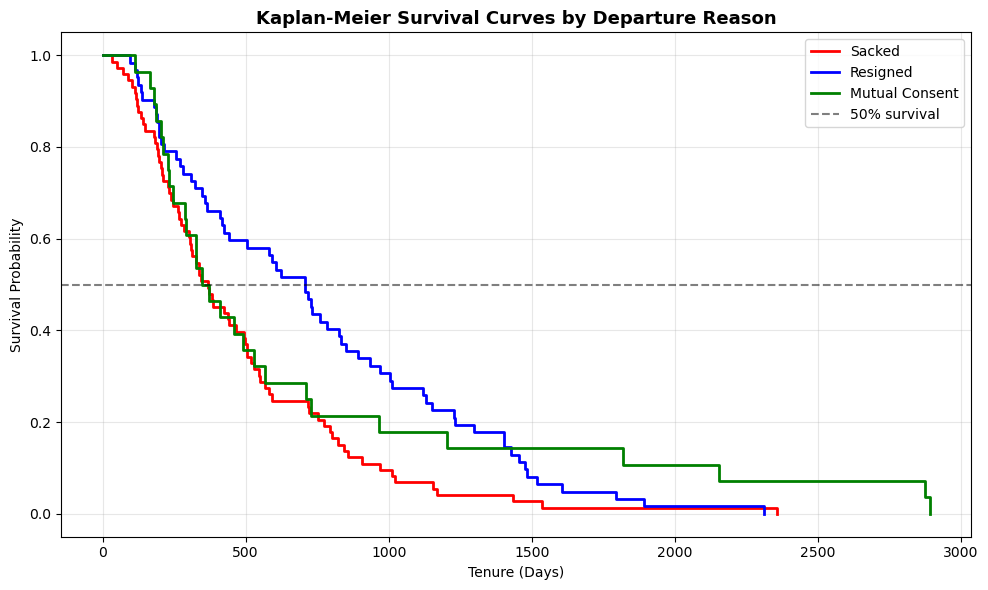

In [19]:
# Group reasons - exclude rare categories for clean comparison
groups = {
    'Sacked': df[df['Reason'] == 'Sacked'],
    'Resigned': df[df['Reason'] == 'Resigned'],
    'Mutual Consent': df[df['Reason'] == 'Mutual Consent']
}

colors = {'Sacked': 'red', 'Resigned': 'blue', 'Mutual Consent': 'green'}

plt.figure(figsize=(10, 6))

for reason, group_df in groups.items():
    times, survival = kaplan_meier(group_df['Tenure_Days'], group_df['Left'])
    plt.step(times, survival, where='post', color=colors[reason], 
             linewidth=2, label=reason)
    
    # Print median for each group
    median_idx = np.where(survival <= 0.5)[0]
    if len(median_idx) > 0:
        print(f"Median survival ({reason}): {times[median_idx[0]]} days")
    else:
        print(f"Median survival ({reason}): not reached")

plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50% survival')
plt.title('Kaplan-Meier Survival Curves by Departure Reason', 
          fontsize=13, fontweight='bold')
plt.xlabel('Tenure (Days)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Survival by Departure Reason - Interpretation

The three survival curves reveal clear differences in tenure across departure reason groups.

Managers who resigned have the longest median survival time at **707 days** — nearly double that of sacked managers at **368 days**. This is intuitive — managers who leave voluntarily tend to do so from a position of strength, either moving to a better club or departing after a successful spell.

Mutual consent departures show a median of **372 days**, almost identical to sackings. 
This supports the widely held view that mutual consent in football is largely a diplomatic framing of what is effectively a sacking, with both parties agreeing to avoid the negative publicity of a formal dismissal.

The mutual consent curve does show a longer tail than the sacked curve however, suggesting that when mutual consent genuinely reflects a two-sided agreement rather than a disguised sacking, it tends to occur after considerably longer tenures.

## Cox Proportional Hazards Model

The Kaplan-Meier curves describe survival patterns across groups but cannot account for multiple covariates simultaneously. The Cox Proportional Hazards model extends this by estimating the effect of each covariate on the **hazard rate** - the instantaneous risk of departure at any given point in time - while controlling all other variables.

The model estimates a **hazard ratio** for each covariate:

-A hazard ratio **above 1.0** means the covariate increases the risk of departure

-A hazard ratio **below 1.0** means the covariate reduces the risk of departure

-A hazard ratio of **1.0** means the covariate has no effect

We include the following covariates:

-**PPG** - points per game during the spell

-**Matches** - total matches in charge

-**Sacked** - binary indicator for whether the manager was sacked (vs other reasons)

In [22]:
from statsmodels.duration.hazard_regression import PHReg

# Prepare covariates
cox_df = df[['Tenure_Days', 'Left', 'PPG', 'Matches']].dropna().copy()
cox_df['Sacked'] = (df.loc[cox_df.index, 'Reason'] == 'Sacked').astype(int)

# Standardise continuous covariates
cox_df['PPG_std'] = (cox_df['PPG'] - cox_df['PPG'].mean()) / cox_df['PPG'].std()
cox_df['Matches_std'] = (cox_df['Matches'] - cox_df['Matches'].mean()) / cox_df['Matches'].std()

# Fit Cox model
model = PHReg(cox_df['Tenure_Days'], 
              cox_df[['PPG_std', 'Matches_std', 'Sacked']], 
              status=cox_df['Left'])

result = model.fit()
print(result.summary())

                          Results: PHReg
Model:                    PH Reg            Sample size:       174
Dependent variable:       Tenure_Days       Num. events:       166
Ties:                     Breslow                                 
------------------------------------------------------------------
             log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
------------------------------------------------------------------
PPG_std      0.0096    0.1087 1.0097   0.0884 0.9296 0.8159 1.2494
Matches_std -1.5349    0.1429 0.2155 -10.7428 0.0000 0.1629 0.2851
Sacked       0.3698    0.1695 1.4475   2.1815 0.0291 1.0383 2.0180
Confidence intervals are for the hazard ratios


### Cox Model Results

The Cox model produces a **hazard ratio (HR)** for each covariate. The hazard rate represents the instantaneous risk of a manager departing at any given point in time. A hazard ratio above 1.0 means the covariate increases this risk, below 1.0 means it reduces it, and exactly 1.0 means no effect. For example, a hazard ratio of 2.0 would mean the risk of departure is doubled.

Each result also carries a **p-value**, which measures whether the effect is statistically significant or likely due to chance. A p-value below 0.05 is the conventional threshold for significance.


1.**Matches in charge (HR = 0.2155, p < 0.001)** is the strongest and most significant finding. A hazard ratio of 0.2155 means that managers with more matches in charge have dramatically lower ongoing risk of departure — approximately 78% lower per additional standard deviation of matches. In plain terms, the longer a manager has already survived, the less likely they are to leave. This reflects a form of tenure momentum where managers who survive early scrutiny become increasingly safe in their role.

2.**Sacking (HR = 1.4455, p = 0.0297)** is statistically significant. Compared to managers who left for other reasons, sacked managers faced roughly 45% higher instantaneous risk of departure at any point during their spell. This is consistent with clubs acting decisively once a decision to remove a manager has been made.

3.**PPG (HR = 1.0107, p = 0.9218)** shows no significant effect whatsoever. A hazard ratio of 1.0107 is essentially 1.0, and the p-value of 0.922 means this result is entirely consistent with chance. Counterintuitively, on-pitch performance as measured by points per game does not significantly predict how long a manager survives in their role. This may suggest that factors beyond results — such as relationships with club ownership, playing style, or squad investment — play a greater role in managerial tenure than raw performance metrics alone.

### Hazard Ratio Forest Plot

A forest plot visualises the hazard ratio and confidence interval for each covariate. The vertical dashed line at HR = 1.0 represents no effect. Covariates whose confidence intervals do not cross this line are statistically significant.

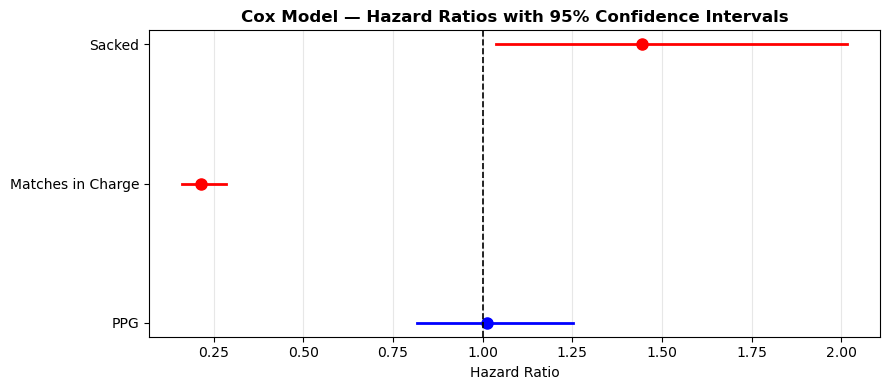

In [25]:
covariates = ['PPG', 'Matches', 'Sacked']
hr = [1.0107, 0.2155, 1.4455]
ci_lower = [0.8167, 0.1628, 1.0369]
ci_upper = [1.2509, 0.2851, 2.0153]

fig, ax = plt.subplots(figsize=(9, 4))

for i, (cov, h, lo, hi) in enumerate(zip(covariates, hr, ci_lower, ci_upper)):
    color = 'red' if lo > 1.0 or hi < 1.0 else 'blue'
    ax.plot([lo, hi], [i, i], color=color, linewidth=2)
    ax.plot(h, i, 'o', color=color, markersize=8)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_yticks(range(len(covariates)))
ax.set_yticklabels(['PPG', 'Matches in Charge', 'Sacked'])
ax.set_xlabel('Hazard Ratio')
ax.set_title('Cox Model — Hazard Ratios with 95% Confidence Intervals',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Forest Plot Interpretation

The forest plot clearly illustrates the relative importance of each covariate. Matches in charge sits well to the left of the no-effect line with a narrow confidence interval, confirming it as the strongest and most precisely estimated predictor of managerial survival.

The sacked indicator sits to the right of 1.0 with its lower confidence interval limit just above the line of no effect, consistent with its borderline significance at p = 0.0297.

PPG straddles 1.0 with a confidence interval spanning from below to above the no-effect line, visually confirming absence of any significant relationship between performance and tenure length.

## Limitations

Several limitations of this analysis should be acknowledged:

**Data quality** — the dataset was manually compiled from Transfermarkt, which while comprehensive, may contain minor inaccuracies in dates or departure reasons, particularly for older spells. Departure reasons for some managers were unclear, therefore they were factored into the category which seemed to suit best accoridng to google research.

**Reason classification** — departure reasons were manually categorised based on available information. The boundary between sacking and mutual consent is often blurred in football, and some classifications required judgement calls that another person might make differently.

**Limited covariates** — the model only includes PPG, matches in charge, and departure reason. Other potentially important factors such as transfer budget, club size, league position at time of departure, or managerial experience are not captured and may impact the results.

**Proportional hazards assumption** — the Cox model assumes that the hazard ratio between groups remains constant over time. This may not hold in practice — for example, the effect of PPG on departure risk may change depending on how long a manager has been in charge.

**Sample size** — while 174 spells is reasonable, splitting by club or era for subgroup analysis would produce small and potentially unreliable estimates.


## Conclusions

This project applied survival analysis to model managerial tenure across Scottish Premiership clubs from the year 2000 onwards, using a manually compiled dataset of managerial spells.

The Kaplan-Meier analysis revealed a median survival time of **460 days** — just over 15 months — with steep early decline followed by a long tail of durable tenures. Managers who resigned survived nearly twice as long as those who were sacked (707 vs 368 days), while mutual consent departures closely mirrored sackings at 372 days, suggesting mutual consent is largely a diplomatic framing of dismissal in Scottish football.

The Cox Proportional Hazards model identified two significant predictors of departure:

- **Matches in charge** significantly reduced the hazard of departure (HR = 0.2155, p < 0.001) — managers who survive early scrutiny face dramatically lower ongoing risk, suggesting tenure momentum plays a key role in managerial stability
  
- **Sacking** was associated with a 45% higher hazard compared to other departure types (HR = 1.4455, p = 0.0297), consistent with clubs acting decisively once a decision is made

Most strikingly, **PPG showed no significant effect on tenure** (HR = 1.0107, p = 0.9218). This counterintuitive finding suggests that on-pitch performance alone does not determine how long a manager survives, implying that wider factors such as club relationships, playing philosophy, and ownership dynamics may be equally or more important.

**Further extensions** could include incorporating club tier or wage budget as covariates, testing the proportional hazards assumption formally, and extending the dataset to include lower Scottish league tiers to assess whether patterns differ across levels of the game.

This project was built entirely in Python using pandas, numpy, matplotlib and statsmodels, and demonstrates the application of Kaplan-Meier estimation, Cox Proportional Hazards regression, and the full data science lifecycle to a real world manually compiled dataset.